In [2]:
# ==========================================================
# Code Cell 1: Import Required Libraries
# This cell imports the libraries required for model development, evaluation, tuning, and output creation.
# ==========================================================

import os
import glob
import json
import time
import shutil
import zipfile
import warnings
import platform

from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from google.colab import files

from sklearn import __version__ as sklearn_version
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    make_scorer
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Environment setup completed successfully.")
print("Python version:", platform.python_version())
print("Scikit-learn version:", sklearn_version)
print("Random state:", RANDOM_STATE)
print("Cross-validation folds:", N_SPLITS)

Environment setup completed successfully.
Python version: 3.12.13
Scikit-learn version: 1.6.1
Random state: 42
Cross-validation folds: 5


In [4]:
# ==========================================================
# Code Cell 2: Upload and Extract Phase 3 Outputs
# This cell locates the Phase 3 ZIP file or asks for it to be uploaded, and then extracts all preprocessing outputs.
# ==========================================================

zip_candidates = glob.glob(
    "/content/Phase_3_Preprocessing_Outputs*.zip"
)

if not zip_candidates:
    print("Please upload Phase_3_Preprocessing_Outputs.zip")
    uploaded_files = files.upload()

    zip_candidates = glob.glob(
        "/content/Phase_3_Preprocessing_Outputs*.zip"
    )

if not zip_candidates:
    raise FileNotFoundError(
        "Phase_3_Preprocessing_Outputs.zip was not found."
    )

ZIP_PATH = max(zip_candidates, key=os.path.getmtime)
EXTRACT_DIR = "/content/phase3_model_inputs"

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)
    extracted_names = zip_file.namelist()

print("ZIP file located:", ZIP_PATH)
print("Extraction folder:", EXTRACT_DIR)
print("Number of extracted files:", len(extracted_names))

for file_name in extracted_names:
    print("-", file_name)

ZIP file located: /content/Phase_3_Preprocessing_Outputs.zip
Extraction folder: /content/phase3_model_inputs
Number of extracted files: 10
- feature_name_mapping.csv
- train_reference.csv
- preprocessor.joblib
- X_test_processed.csv
- y_test.csv
- cleaned_telco_churn.csv
- test_reference.csv
- X_train_processed.csv
- preprocessing_metadata.json
- y_train.csv


In [6]:
# ==========================================================
# Code Cell 3: Load Phase 3 Processed Datasets
# This cell loads the processed training and testing data, target files, and customer reference datasets.
# ==========================================================

def find_extracted_file(file_name):
    matches = glob.glob(
        os.path.join(EXTRACT_DIR, "**", file_name),
        recursive=True
    )

    matches = [
        path for path in matches
        if "__MACOSX" not in path
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Required file was not found: {file_name}"
        )

    return matches[0]


X_train_path = find_extracted_file("X_train_processed.csv")
X_test_path = find_extracted_file("X_test_processed.csv")
y_train_path = find_extracted_file("y_train.csv")
y_test_path = find_extracted_file("y_test.csv")
train_reference_path = find_extracted_file("train_reference.csv")
test_reference_path = find_extracted_file("test_reference.csv")
feature_mapping_path = find_extracted_file("feature_name_mapping.csv")
metadata_path = find_extracted_file("preprocessing_metadata.json")

X_train = pd.read_csv(X_train_path).reset_index(drop=True)
X_test = pd.read_csv(X_test_path).reset_index(drop=True)

y_train = (
    pd.read_csv(y_train_path)
    .iloc[:, 0]
    .astype(int)
    .reset_index(drop=True)
)

y_test = (
    pd.read_csv(y_test_path)
    .iloc[:, 0]
    .astype(int)
    .reset_index(drop=True)
)

train_reference = (
    pd.read_csv(train_reference_path)
    .reset_index(drop=True)
)

test_reference = (
    pd.read_csv(test_reference_path)
    .reset_index(drop=True)
)

feature_name_mapping = pd.read_csv(feature_mapping_path)

with open(metadata_path, "r", encoding="utf-8") as metadata_file:
    preprocessing_metadata = json.load(metadata_file)

print("All Phase 3 datasets loaded successfully.")
print()
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Train reference shape:", train_reference.shape)
print("Test reference shape:", test_reference.shape)

All Phase 3 datasets loaded successfully.

X_train shape: (5625, 45)
X_test shape: (1407, 45)
y_train shape: (5625,)
y_test shape: (1407,)
Train reference shape: (5625, 22)
Test reference shape: (1407, 22)


In [7]:
# ==========================================================
# Code Cell 4: Validate Model Development Inputs
# This cell confirms that the datasets have matching shapes, valid numerical values, aligned targets, and customer IDs.
# ==========================================================

validation_checks = {
    "Training rows match target":
        len(X_train) == len(y_train),

    "Testing rows match target":
        len(X_test) == len(y_test),

    "Training columns match testing columns":
        list(X_train.columns) == list(X_test.columns),

    "Training reference rows match":
        len(train_reference) == len(X_train),

    "Testing reference rows match":
        len(test_reference) == len(X_test),

    "No training missing values":
        int(X_train.isna().sum().sum()) == 0,

    "No testing missing values":
        int(X_test.isna().sum().sum()) == 0,

    "No training infinite values":
        np.isfinite(X_train.to_numpy()).all(),

    "No testing infinite values":
        np.isfinite(X_test.to_numpy()).all(),

    "Training target is binary":
        set(y_train.unique()).issubset({0, 1}),

    "Testing target is binary":
        set(y_test.unique()).issubset({0, 1}),

    "All training features are numeric":
        all(pd.api.types.is_numeric_dtype(dtype)
            for dtype in X_train.dtypes),

    "All testing features are numeric":
        all(pd.api.types.is_numeric_dtype(dtype)
            for dtype in X_test.dtypes)
}

for check_name, check_result in validation_checks.items():
    print(f"{check_name}: {check_result}")

if not all(validation_checks.values()):
    raise ValueError(
        "One or more dataset validation checks failed."
    )

if "ChurnEncoded" in train_reference.columns:
    train_alignment = (
        train_reference["ChurnEncoded"]
        .astype(int)
        .reset_index(drop=True)
        .equals(y_train)
    )
else:
    train_alignment = False

if "ChurnEncoded" in test_reference.columns:
    test_alignment = (
        test_reference["ChurnEncoded"]
        .astype(int)
        .reset_index(drop=True)
        .equals(y_test)
    )
else:
    test_alignment = False

print()
print("Training reference target alignment:", train_alignment)
print("Testing reference target alignment:", test_alignment)

if not train_alignment or not test_alignment:
    raise ValueError(
        "Reference data and target values are not aligned."
    )

print()
print("Training target distribution:")
print(y_train.value_counts().sort_index())

print()
print("Testing target distribution:")
print(y_test.value_counts().sort_index())

print()
print("Input validation completed successfully.")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Processed model features:", X_train.shape[1])

Training rows match target: True
Testing rows match target: True
Training columns match testing columns: True
Training reference rows match: True
Testing reference rows match: True
No training missing values: True
No testing missing values: True
No training infinite values: True
No testing infinite values: True
Training target is binary: True
Testing target is binary: True
All training features are numeric: True
All testing features are numeric: True

Training reference target alignment: True
Testing reference target alignment: True

Training target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64

Input validation completed successfully.
Training records: 5625
Testing records: 1407
Processed model features: 45


In [8]:
# ==========================================================
# Code Cell 5: Define Evaluation Settings and Functions
# This cell creates the stratified cross-validation strategy,evaluation metrics, and a reusable metric function.
# ==========================================================

cross_validation = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}


def calculate_binary_metrics(
    y_true,
    y_predicted,
    y_probability
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_predicted
        ),
        "Precision": precision_score(
            y_true,
            y_predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_predicted,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_predicted,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_probability
        ),
        "Brier_Score": brier_score_loss(
            y_true,
            y_probability
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


print("Evaluation settings created successfully.")
print("Positive class: Churn = 1")
print("Cross-validation method: Stratified 5-fold")
print("The test dataset will not be used during model selection.")

Evaluation settings created successfully.
Positive class: Churn = 1
Cross-validation method: Stratified 5-fold
The test dataset will not be used during model selection.


In [9]:
# ==========================================================
# Code Cell 6: Define Baseline Classification Models
# This cell defines the five models that will be compared using only cross-validation on the training dataset.
# ==========================================================

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ),

    "Weighted Logistic Regression": LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
}

print("Baseline models created:")

for model_name in baseline_models:
    print("-", model_name)

Baseline models created:
- Logistic Regression
- Weighted Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [10]:
# ==========================================================
# Code Cell 7: Evaluate Baseline Models with Cross-Validation
# This cell evaluates every model using stratified five-fold cross-validation and out-of-fold training predictions.
# ==========================================================

baseline_comparison_rows = []
cross_validation_fold_rows = []
out_of_fold_results = {}

for model_name, model in baseline_models.items():

    print(f"Evaluating: {model_name}")
    start_time = time.time()

    cv_scores = cross_validate(
        estimator=clone(model),
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1
    )

    oof_probabilities = cross_val_predict(
        estimator=clone(model),
        X=X_train,
        y=y_train,
        cv=cross_validation,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_predictions = (
        oof_probabilities >= 0.50
    ).astype(int)

    oof_metrics = calculate_binary_metrics(
        y_train,
        oof_predictions,
        oof_probabilities
    )

    elapsed_time = time.time() - start_time

    baseline_comparison_rows.append({
        "Model": model_name,

        "OOF_Accuracy": oof_metrics["Accuracy"],
        "OOF_Precision": oof_metrics["Precision"],
        "OOF_Recall": oof_metrics["Recall"],
        "OOF_F1": oof_metrics["F1"],
        "OOF_ROC_AUC": oof_metrics["ROC_AUC"],
        "OOF_PR_AUC": oof_metrics["PR_AUC"],
        "OOF_Brier_Score": oof_metrics["Brier_Score"],

        "CV_Accuracy_Mean":
            cv_scores["test_accuracy"].mean(),

        "CV_Precision_Mean":
            cv_scores["test_precision"].mean(),

        "CV_Recall_Mean":
            cv_scores["test_recall"].mean(),

        "CV_F1_Mean":
            cv_scores["test_f1"].mean(),

        "CV_F1_Std":
            cv_scores["test_f1"].std(),

        "CV_ROC_AUC_Mean":
            cv_scores["test_roc_auc"].mean(),

        "CV_ROC_AUC_Std":
            cv_scores["test_roc_auc"].std(),

        "CV_PR_AUC_Mean":
            cv_scores["test_average_precision"].mean(),

        "CV_PR_AUC_Std":
            cv_scores["test_average_precision"].std(),

        "Train_F1_Mean":
            cv_scores["train_f1"].mean(),

        "Train_ROC_AUC_Mean":
            cv_scores["train_roc_auc"].mean(),

        "F1_Overfitting_Gap":
            cv_scores["train_f1"].mean()
            - cv_scores["test_f1"].mean(),

        "ROC_AUC_Overfitting_Gap":
            cv_scores["train_roc_auc"].mean()
            - cv_scores["test_roc_auc"].mean(),

        "TN": oof_metrics["TN"],
        "FP": oof_metrics["FP"],
        "FN": oof_metrics["FN"],
        "TP": oof_metrics["TP"],

        "Evaluation_Time_Seconds": elapsed_time
    })

    for fold_number in range(N_SPLITS):
        cross_validation_fold_rows.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Validation_Accuracy":
                cv_scores["test_accuracy"][fold_number],
            "Validation_Precision":
                cv_scores["test_precision"][fold_number],
            "Validation_Recall":
                cv_scores["test_recall"][fold_number],
            "Validation_F1":
                cv_scores["test_f1"][fold_number],
            "Validation_ROC_AUC":
                cv_scores["test_roc_auc"][fold_number],
            "Validation_PR_AUC":
                cv_scores["test_average_precision"][fold_number],
            "Training_F1":
                cv_scores["train_f1"][fold_number],
            "Training_ROC_AUC":
                cv_scores["train_roc_auc"][fold_number]
        })

    out_of_fold_results[model_name] = {
        "probabilities": oof_probabilities,
        "predictions": oof_predictions
    }

    print(
        f"Completed in {elapsed_time:.2f} seconds."
    )
    print()


baseline_comparison_df = pd.DataFrame(
    baseline_comparison_rows
).sort_values(
    by=[
        "CV_PR_AUC_Mean",
        "CV_ROC_AUC_Mean",
        "CV_F1_Mean"
    ],
    ascending=False
).reset_index(drop=True)

cross_validation_results_df = pd.DataFrame(
    cross_validation_fold_rows
)

print("Baseline cross-validation completed successfully.")

Evaluating: Logistic Regression
Completed in 4.83 seconds.

Evaluating: Weighted Logistic Regression
Completed in 0.66 seconds.

Evaluating: Decision Tree
Completed in 0.78 seconds.

Evaluating: Random Forest
Completed in 15.51 seconds.

Evaluating: Gradient Boosting
Completed in 10.24 seconds.

Baseline cross-validation completed successfully.


In [11]:
# ==========================================================
# Code Cell 8: Display Baseline Model Comparison
# This cell presents the main performance and stability metrics produced from training cross-validation.
# ==========================================================

comparison_columns = [
    "Model",
    "CV_Accuracy_Mean",
    "CV_Precision_Mean",
    "CV_Recall_Mean",
    "CV_F1_Mean",
    "CV_ROC_AUC_Mean",
    "CV_PR_AUC_Mean",
    "CV_F1_Std",
    "CV_ROC_AUC_Std",
    "F1_Overfitting_Gap",
    "ROC_AUC_Overfitting_Gap"
]

print("Baseline Model Comparison")
print("Results are based only on training cross-validation.")
print()

display(
    baseline_comparison_df[
        comparison_columns
    ].round(4)
)

Baseline Model Comparison
Results are based only on training cross-validation.



,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean,CV_PR_AUC_Mean,CV_F1_Std,CV_ROC_AUC_Std,F1_Overfitting_Gap,ROC_AUC_Overfitting_Gap
0,Gradient Boosting,0.8041,0.6719,0.5157,0.5832,0.8494,0.6683,0.0043,0.0051,0.0256,0.0142
1,Logistic Regression,0.8025,0.6538,0.5472,0.5955,0.8461,0.6601,0.0233,0.0052,0.0056,0.0050
2,Weighted Logistic Regression,0.7520,0.5218,0.8027,0.6324,0.8459,0.6589,0.0068,0.0054,0.0060,0.0050
3,Random Forest,0.7835,0.5777,0.6903,0.6289,0.8437,0.6539,0.0037,0.0059,0.1841,0.1202
4,Decision Tree,0.7358,0.5038,0.7967,0.6157,0.8301,0.6054,0.0083,0.0070,0.0239,0.0259


In [12]:
# ==========================================================
# Code Cell 9: Display Baseline Classification Reports
# This cell prints the churn and non-churn classification reports using out-of-fold training predictions.
# ==========================================================

for model_name in baseline_models:

    predictions = out_of_fold_results[
        model_name
    ]["predictions"]

    print("=" * 75)
    print(model_name)
    print("Out-of-Fold Classification Report")
    print("=" * 75)

    print(
        classification_report(
            y_train,
            predictions,
            labels=[0, 1],
            target_names=[
                "Non-Churn (0)",
                "Churn (1)"
            ],
            digits=4,
            zero_division=0
        )
    )

Logistic Regression
Out-of-Fold Classification Report
               precision    recall  f1-score   support

Non-Churn (0)     0.8452    0.8949    0.8693      4130
    Churn (1)     0.6534    0.5472    0.5956      1495

     accuracy                         0.8025      5625
    macro avg     0.7493    0.7210    0.7324      5625
 weighted avg     0.7942    0.8025    0.7966      5625

Weighted Logistic Regression
Out-of-Fold Classification Report
               precision    recall  f1-score   support

Non-Churn (0)     0.9113    0.7337    0.8129      4130
    Churn (1)     0.5217    0.8027    0.6324      1495

     accuracy                         0.7520      5625
    macro avg     0.7165    0.7682    0.7226      5625
 weighted avg     0.8077    0.7520    0.7649      5625

Decision Tree
Out-of-Fold Classification Report
               precision    recall  f1-score   support

Non-Churn (0)     0.9065    0.7138    0.7987      4130
    Churn (1)     0.5019    0.7967    0.6158      1495

  

<Figure size 600x500 with 0 Axes>

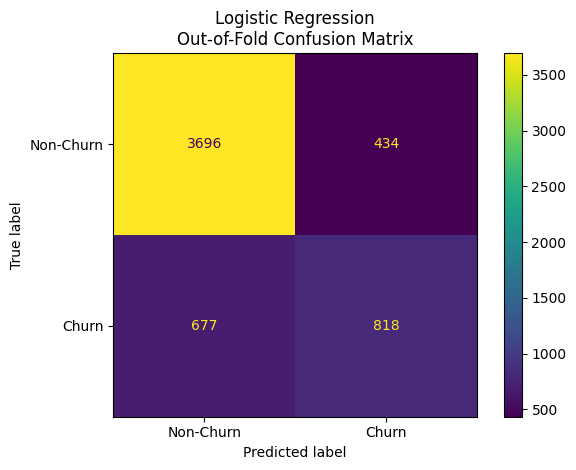

<Figure size 600x500 with 0 Axes>

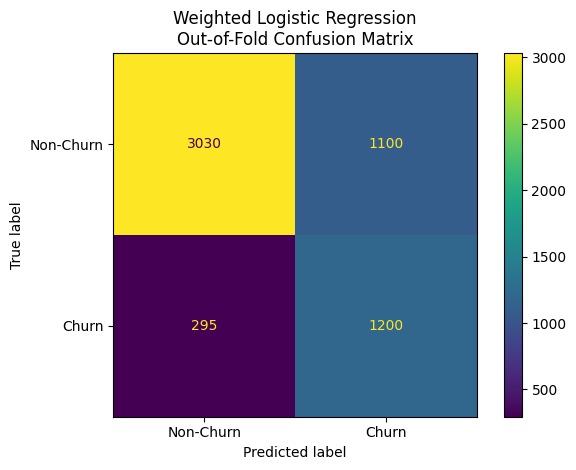

<Figure size 600x500 with 0 Axes>

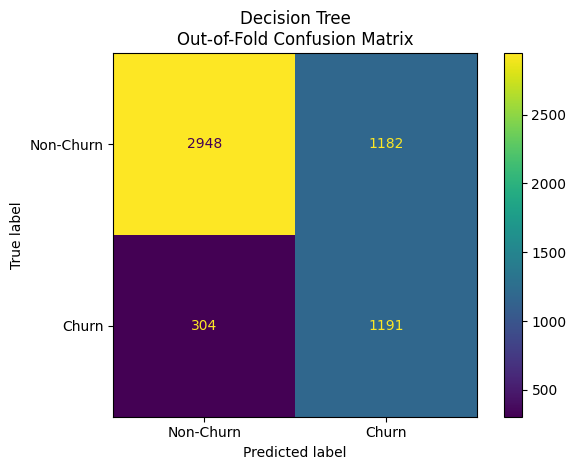

<Figure size 600x500 with 0 Axes>

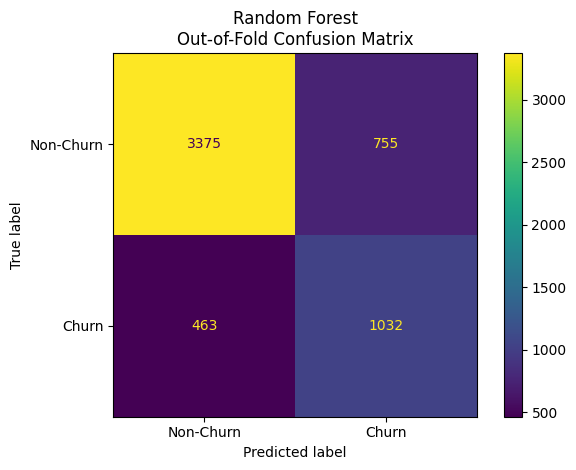

<Figure size 600x500 with 0 Axes>

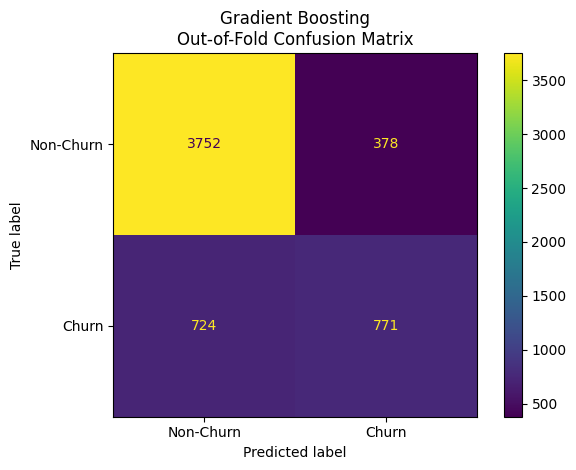

In [13]:
# ==========================================================
# Code Cell 10: Display Baseline Confusion Matrices
# This cell displays one out-of-fold confusion matrix for every baseline model.
# ==========================================================

for model_name in baseline_models:

    predictions = out_of_fold_results[
        model_name
    ]["predictions"]

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_train,
        predictions,
        display_labels=[
            "Non-Churn",
            "Churn"
        ],
        values_format="d"
    )

    plt.title(
        f"{model_name}\n"
        "Out-of-Fold Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

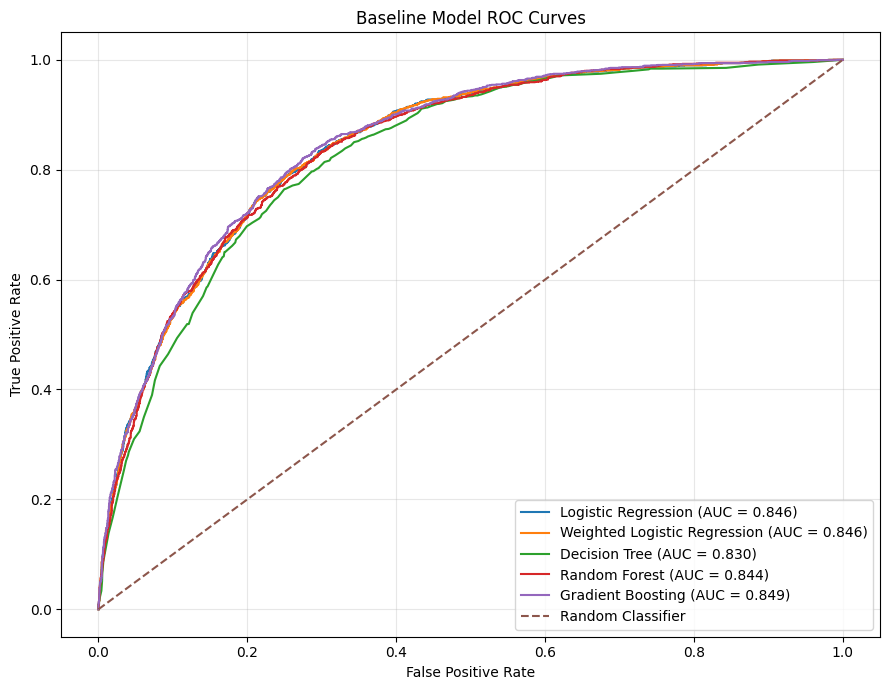

In [14]:
# ==========================================================
# Code Cell 11: Compare Baseline ROC Curves
# This cell compares the ability of the baseline models to rank churn and non-churn customers.
# ==========================================================

plt.figure(figsize=(9, 7))

for model_name in baseline_models:

    probabilities = out_of_fold_results[
        model_name
    ]["probabilities"]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_train,
        probabilities
    )

    auc_value = roc_auc_score(
        y_train,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Model ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

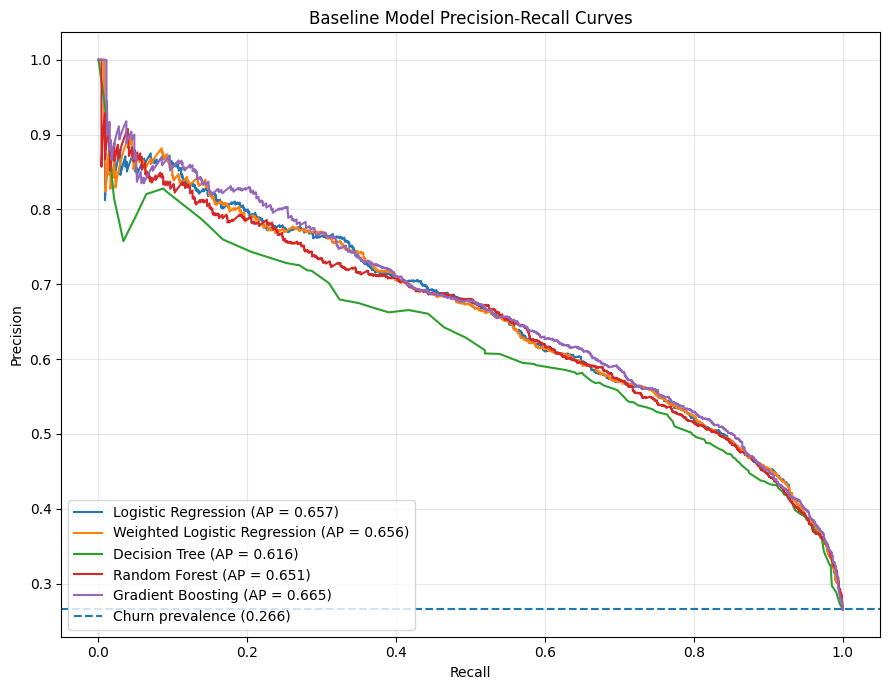

In [15]:
# ==========================================================
# Code Cell 12: Compare Precision-Recall Curves
# This cell compares model performance on the smaller churn class using out-of-fold probabilities.
# ==========================================================

plt.figure(figsize=(9, 7))

positive_class_rate = y_train.mean()

for model_name in baseline_models:

    probabilities = out_of_fold_results[
        model_name
    ]["probabilities"]

    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_train,
            probabilities
        )
    )

    average_precision = average_precision_score(
        y_train,
        probabilities
    )

    plt.plot(
        recall_values,
        precision_values,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.axhline(
    y=positive_class_rate,
    linestyle="--",
    label=(
        "Churn prevalence "
        f"({positive_class_rate:.3f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline Model Precision-Recall Curves")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ==========================================================
# Code Cell 13: Examine Model Stability and Overfitting
# This cell classifies the difference between training and validation performance for each baseline model.
# ==========================================================

def classify_overfitting_gap(gap_value):

    if gap_value <= 0.03:
        return "Low"

    if gap_value <= 0.08:
        return "Moderate"

    return "High"


stability_analysis_df = baseline_comparison_df[
    [
        "Model",
        "CV_F1_Mean",
        "CV_F1_Std",
        "Train_F1_Mean",
        "F1_Overfitting_Gap",
        "CV_ROC_AUC_Mean",
        "CV_ROC_AUC_Std",
        "Train_ROC_AUC_Mean",
        "ROC_AUC_Overfitting_Gap"
    ]
].copy()

stability_analysis_df["F1_Overfitting_Risk"] = (
    stability_analysis_df[
        "F1_Overfitting_Gap"
    ].apply(classify_overfitting_gap)
)

stability_analysis_df[
    "ROC_AUC_Overfitting_Risk"
] = stability_analysis_df[
    "ROC_AUC_Overfitting_Gap"
].apply(classify_overfitting_gap)

print("Model Stability and Overfitting Analysis")
print()

display(
    stability_analysis_df.round(4)
)

Model Stability and Overfitting Analysis



,Model,CV_F1_Mean,CV_F1_Std,Train_F1_Mean,F1_Overfitting_Gap,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Train_ROC_AUC_Mean,ROC_AUC_Overfitting_Gap,F1_Overfitting_Risk,ROC_AUC_Overfitting_Risk
0,Gradient Boosting,0.5832,0.0043,0.6088,0.0256,0.8494,0.0051,0.8637,0.0142,Low,Low
1,Logistic Regression,0.5955,0.0233,0.6011,0.0056,0.8461,0.0052,0.8511,0.0050,Low,Low
2,Weighted Logistic Regression,0.6324,0.0068,0.6384,0.0060,0.8459,0.0054,0.8509,0.0050,Low,Low
3,Random Forest,0.6289,0.0037,0.8130,0.1841,0.8437,0.0059,0.9640,0.1202,High,High
4,Decision Tree,0.6157,0.0083,0.6396,0.0239,0.8301,0.0070,0.8559,0.0259,Low,Low


In [17]:
# ==========================================================
# Code Cell 14: Tune Logistic Regression
# This cell tests a limited set of regularization strengths and class-weight settings using training data only.
# ==========================================================

logistic_parameter_grid = {
    "C": [
        0.05,
        0.10,
        0.50,
        1.00,
        2.00,
        5.00
    ],

    "class_weight": [
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2.0}
    ]
}

logistic_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ),
    param_grid=logistic_parameter_grid,
    scoring=scoring_metrics,
    refit="average_precision",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=True
)

logistic_search.fit(
    X_train,
    y_train
)

logistic_best_index = logistic_search.best_index_

print("Logistic Regression tuning completed.")
print()
print("Best parameters:")
print(logistic_search.best_params_)
print()
print(
    "Best cross-validation PR-AUC:",
    round(
        logistic_search.best_score_,
        4
    )
)
print(
    "Cross-validation ROC-AUC:",
    round(
        logistic_search.cv_results_[
            "mean_test_roc_auc"
        ][logistic_best_index],
        4
    )
)
print(
    "Cross-validation F1:",
    round(
        logistic_search.cv_results_[
            "mean_test_f1"
        ][logistic_best_index],
        4
    )
)
print(
    "Cross-validation churn recall:",
    round(
        logistic_search.cv_results_[
            "mean_test_recall"
        ][logistic_best_index],
        4
    )
)

Logistic Regression tuning completed.

Best parameters:
{'C': 1.0, 'class_weight': None}

Best cross-validation PR-AUC: 0.6601
Cross-validation ROC-AUC: 0.8461
Cross-validation F1: 0.5955
Cross-validation churn recall: 0.5472


In [18]:
# ==========================================================
# Code Cell 15: Tune Gradient Boosting
# This cell performs a limited randomized parameter search using training cross-validation only.
# ==========================================================

gradient_boosting_parameter_options = {
    "n_estimators": [
        100,
        150,
        200
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.10
    ],

    "max_depth": [
        1,
        2,
        3
    ],

    "min_samples_leaf": [
        10,
        20,
        30
    ],

    "subsample": [
        0.80,
        1.00
    ]
}

gradient_boosting_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    param_distributions=(
        gradient_boosting_parameter_options
    ),
    n_iter=20,
    scoring=scoring_metrics,
    refit="average_precision",
    cv=cross_validation,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

gradient_boosting_search.fit(
    X_train,
    y_train
)

gradient_best_index = (
    gradient_boosting_search.best_index_
)

print("Gradient Boosting tuning completed.")
print()
print("Best parameters:")
print(gradient_boosting_search.best_params_)
print()
print(
    "Best cross-validation PR-AUC:",
    round(
        gradient_boosting_search.best_score_,
        4
    )
)
print(
    "Cross-validation ROC-AUC:",
    round(
        gradient_boosting_search.cv_results_[
            "mean_test_roc_auc"
        ][gradient_best_index],
        4
    )
)
print(
    "Cross-validation F1:",
    round(
        gradient_boosting_search.cv_results_[
            "mean_test_f1"
        ][gradient_best_index],
        4
    )
)
print(
    "Cross-validation churn recall:",
    round(
        gradient_boosting_search.cv_results_[
            "mean_test_recall"
        ][gradient_best_index],
        4
    )
)

Gradient Boosting tuning completed.

Best parameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 30, 'max_depth': 2, 'learning_rate': 0.05}

Best cross-validation PR-AUC: 0.6693
Cross-validation ROC-AUC: 0.8496
Cross-validation F1: 0.5786
Cross-validation churn recall: 0.5023


In [20]:
# ==========================================================
# Code Cell 16: Compare Tuned Model Candidates
# This cell compares the tuned models and selects the final algorithm using training cross-validation results only.
# ==========================================================

search_objects = {
    "Tuned Logistic Regression":
        logistic_search,

    "Tuned Gradient Boosting":
        gradient_boosting_search
}

tuned_candidate_rows = []

for candidate_name, search_object in search_objects.items():

    best_index = search_object.best_index_
    cv_results = search_object.cv_results_

    tuned_candidate_rows.append({
        "Model": candidate_name,

        "CV_Accuracy":
            cv_results[
                "mean_test_accuracy"
            ][best_index],

        "CV_Precision":
            cv_results[
                "mean_test_precision"
            ][best_index],

        "CV_Recall":
            cv_results[
                "mean_test_recall"
            ][best_index],

        "CV_F1":
            cv_results[
                "mean_test_f1"
            ][best_index],

        "CV_ROC_AUC":
            cv_results[
                "mean_test_roc_auc"
            ][best_index],

        "CV_PR_AUC":
            cv_results[
                "mean_test_average_precision"
            ][best_index],

        "CV_PR_AUC_Std":
            cv_results[
                "std_test_average_precision"
            ][best_index],

        "Training_F1":
            cv_results[
                "mean_train_f1"
            ][best_index],

        "F1_Overfitting_Gap":
            cv_results[
                "mean_train_f1"
            ][best_index]
            - cv_results[
                "mean_test_f1"
            ][best_index],

        "Best_Parameters":
            str(search_object.best_params_)
    })


tuned_candidate_comparison_df = pd.DataFrame(
    tuned_candidate_rows
).sort_values(
    by=[
        "CV_PR_AUC",
        "CV_ROC_AUC",
        "CV_F1"
    ],
    ascending=False
).reset_index(drop=True)

print("Tuned Candidate Comparison")
print("No test-set results were used for this selection.")
print()

display(
    tuned_candidate_comparison_df.round(4)
)

selected_candidate_name = (
    tuned_candidate_comparison_df
    .iloc[0]["Model"]
)

selected_search = search_objects[
    selected_candidate_name
]

selected_model_template = clone(
    selected_search.best_estimator_
)

selected_best_parameters = (
    selected_search.best_params_
)

print()
print("Selected model:", selected_candidate_name)
print("Selected parameters:")
print(selected_best_parameters)
print()
print(
    "Selection basis: highest cross-validation "
    "PR-AUC, followed by ROC-AUC and F1-score."
)

Tuned Candidate Comparison
No test-set results were used for this selection.



,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,CV_PR_AUC,CV_PR_AUC_Std,Training_F1,F1_Overfitting_Gap,Best_Parameters
0,Tuned Gradient Boosting,0.8057,0.6837,0.5023,0.5786,0.8496,0.6693,0.0113,0.5952,0.0165,"{'subsample': 0.8, 'n_estimators': 100, 'min_s..."
1,Tuned Logistic Regression,0.8025,0.6538,0.5472,0.5955,0.8461,0.6601,0.0115,0.6011,0.0056,"{'C': 1.0, 'class_weight': None}"



Selected model: Tuned Gradient Boosting
Selected parameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 30, 'max_depth': 2, 'learning_rate': 0.05}

Selection basis: highest cross-validation PR-AUC, followed by ROC-AUC and F1-score.


In [22]:
# ==========================================================
# Code Cell 17: Analyze and Select Prediction Threshold
# This cell uses out-of-fold training probabilities to find a threshold that achieves at least 80% churn recall.
# ==========================================================

TARGET_CHURN_RECALL = 0.80

selected_oof_probabilities = cross_val_predict(
    estimator=clone(selected_model_template),
    X=X_train,
    y=y_train,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []

threshold_values = np.round(
    np.arange(
        0.05,
        0.96,
        0.01
    ),
    2
)

for threshold in threshold_values:

    threshold_predictions = (
        selected_oof_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": float(threshold),

        "Accuracy": accuracy_score(
            y_train,
            threshold_predictions
        ),

        "Precision": precision_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),

        "F2": fbeta_score(
            y_train,
            threshold_predictions,
            beta=2,
            zero_division=0
        ),

        "Predicted_Churn_Count":
            int(threshold_predictions.sum())
    })


threshold_analysis_df = pd.DataFrame(
    threshold_rows
)

valid_thresholds = threshold_analysis_df[
    threshold_analysis_df["Recall"]
    >= TARGET_CHURN_RECALL
].copy()

if len(valid_thresholds) > 0:

    selected_threshold_row = (
        valid_thresholds
        .sort_values(
            by=[
                "F1",
                "Precision",
                "Accuracy"
            ],
            ascending=False
        )
        .iloc[0]
    )

else:

    selected_threshold_row = (
        threshold_analysis_df
        .sort_values(
            by=[
                "Recall",
                "F1"
            ],
            ascending=False
        )
        .iloc[0]
    )


selected_threshold = float(
    selected_threshold_row["Threshold"]
)

default_oof_predictions = (
    selected_oof_probabilities >= 0.50
).astype(int)

selected_oof_predictions = (
    selected_oof_probabilities
    >= selected_threshold
).astype(int)

default_oof_metrics = calculate_binary_metrics(
    y_train,
    default_oof_predictions,
    selected_oof_probabilities
)

selected_oof_metrics = calculate_binary_metrics(
    y_train,
    selected_oof_predictions,
    selected_oof_probabilities
)

oof_threshold_comparison_df = pd.DataFrame([
    {
        "Threshold_Type": "Default",
        "Threshold": 0.50,
        **default_oof_metrics
    },
    {
        "Threshold_Type": "Selected",
        "Threshold": selected_threshold,
        **selected_oof_metrics
    }
])

print("Selected threshold:", selected_threshold)
print(
    "Target churn recall:",
    TARGET_CHURN_RECALL
)
print()
print(
    "Top thresholds satisfying the recall target:"
)

display(
    valid_thresholds
    .sort_values(
        by=[
            "F1",
            "Precision"
        ],
        ascending=False
    )
    .head(10)
    .round(4)
)

print()
print("Out-of-Fold Threshold Comparison")

display(
    oof_threshold_comparison_df[
        [
            "Threshold_Type",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "PR_AUC",
            "FP",
            "FN"
        ]
    ].round(4)
)

Selected threshold: 0.27
Target churn recall: 0.8

Top thresholds satisfying the recall target:


,Threshold,Accuracy,Precision,Recall,F1,F2,Predicted_Churn_Count
22,0.2700,0.7579,0.5293,0.8027,0.6380,0.7275,2267
21,0.2600,0.7534,0.5232,0.8140,0.6370,0.7326,2326
20,0.2500,0.7502,0.5191,0.8194,0.6355,0.7344,2360
19,0.2400,0.7461,0.5139,0.8274,0.6340,0.7375,2407
18,0.2300,0.7394,0.5059,0.8321,0.6292,0.7371,2459
17,0.2200,0.7351,0.5010,0.8408,0.6279,0.7404,2509
16,0.2100,0.7308,0.4963,0.8482,0.6262,0.7428,2555
15,0.2000,0.7234,0.4883,0.8548,0.6216,0.7433,2617
14,0.1900,0.7150,0.4799,0.8642,0.6171,0.7449,2692
13,0.1800,0.7058,0.4712,0.8742,0.6123,0.7465,2774



Out-of-Fold Threshold Comparison


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,FP,FN
0,Default,0.5000,0.8057,0.6827,0.5023,0.5788,0.8492,0.6658,349,744
1,Selected,0.2700,0.7579,0.5293,0.8027,0.6380,0.8492,0.6658,1067,295


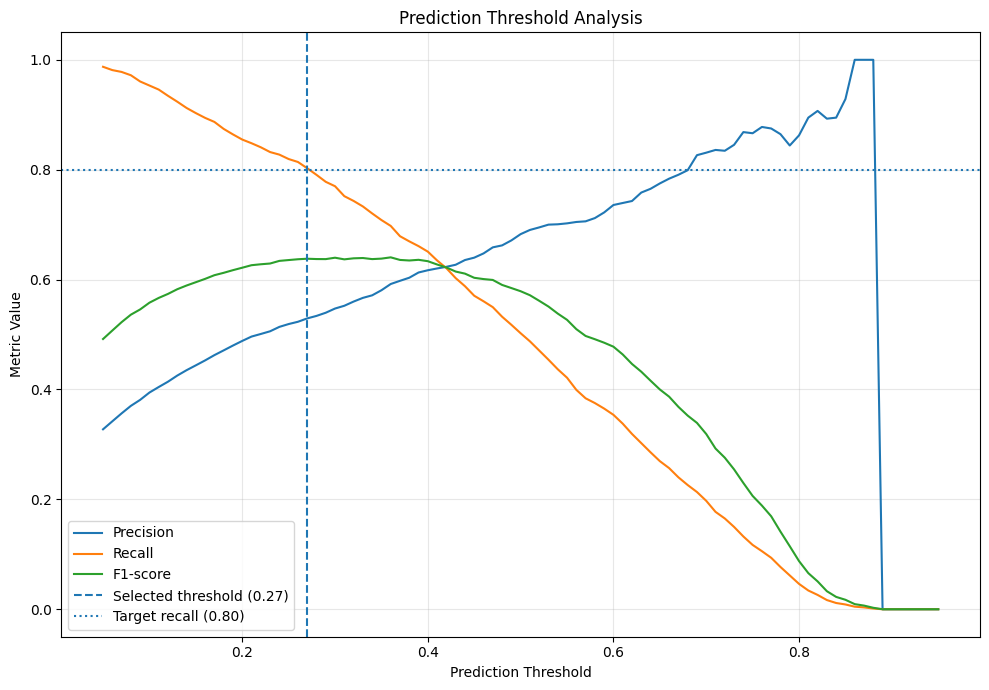

In [24]:
# ==========================================================
# Code Cell 18: Plot Threshold Performance Trade-Offs
# This cell shows how churn precision, recall, and F1-score change across different probability thresholds.
# ==========================================================

plt.figure(figsize=(10, 7))

plt.plot(
    threshold_analysis_df["Threshold"],
    threshold_analysis_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_analysis_df["Threshold"],
    threshold_analysis_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_analysis_df["Threshold"],
    threshold_analysis_df["F1"],
    label="F1-score"
)

plt.axvline(
    x=selected_threshold,
    linestyle="--",
    label=(
        "Selected threshold "
        f"({selected_threshold:.2f})"
    )
)

plt.axhline(
    y=TARGET_CHURN_RECALL,
    linestyle=":",
    label=(
        "Target recall "
        f"({TARGET_CHURN_RECALL:.2f})"
    )
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Metric Value")
plt.title("Prediction Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# ==========================================================
# Code Cell 19: Train and Evaluate the Final Model
# This cell trains the selected model on all training records and evaluates it once on the independent test dataset.
# ==========================================================

final_model = clone(
    selected_model_template
)

final_model.fit(
    X_train,
    y_train
)

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

test_predictions_default = (
    test_probabilities >= 0.50
).astype(int)

test_predictions_selected = (
    test_probabilities >= selected_threshold
).astype(int)

default_test_metrics = calculate_binary_metrics(
    y_test,
    test_predictions_default,
    test_probabilities
)

selected_test_metrics = calculate_binary_metrics(
    y_test,
    test_predictions_selected,
    test_probabilities
)

test_metrics_df = pd.DataFrame([
    {
        "Evaluation": "Default Threshold",
        "Threshold": 0.50,
        **default_test_metrics
    },
    {
        "Evaluation": "Selected Threshold",
        "Threshold": selected_threshold,
        **selected_test_metrics
    }
])

print("Final model:", selected_candidate_name)
print("Independent test evaluation completed.")
print()

display(
    test_metrics_df[
        [
            "Evaluation",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "PR_AUC",
            "Brier_Score",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ].round(4)
)

print()
print(
    "False negatives represent actual churn customers "
    "incorrectly predicted as non-churn."
)

print(
    "False positives represent non-churn customers "
    "incorrectly predicted as churn."
)

Final model: Tuned Gradient Boosting
Independent test evaluation completed.



,Evaluation,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score,TN,FP,FN,TP
0,Default Threshold,0.5000,0.7960,0.6495,0.5053,0.5684,0.8383,0.6520,0.1386,931,102,185,189
1,Selected Threshold,0.2700,0.7306,0.4959,0.8075,0.6144,0.8383,0.6520,0.1386,726,307,72,302



False negatives represent actual churn customers incorrectly predicted as non-churn.
False positives represent non-churn customers incorrectly predicted as churn.


Default Threshold 0.50
Independent Test Classification Report
               precision    recall  f1-score   support

Non-Churn (0)     0.8342    0.9013    0.8664      1033
    Churn (1)     0.6495    0.5053    0.5684       374

     accuracy                         0.7960      1407
    macro avg     0.7419    0.7033    0.7174      1407
 weighted avg     0.7851    0.7960    0.7872      1407



<Figure size 600x500 with 0 Axes>

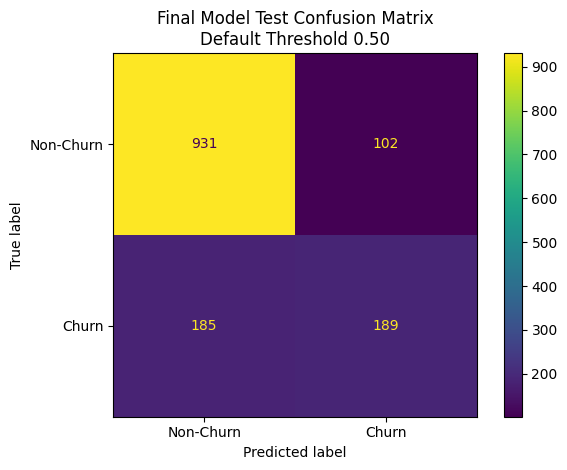

Selected Threshold 0.27
Independent Test Classification Report
               precision    recall  f1-score   support

Non-Churn (0)     0.9098    0.7028    0.7930      1033
    Churn (1)     0.4959    0.8075    0.6144       374

     accuracy                         0.7306      1407
    macro avg     0.7028    0.7551    0.7037      1407
 weighted avg     0.7998    0.7306    0.7455      1407



<Figure size 600x500 with 0 Axes>

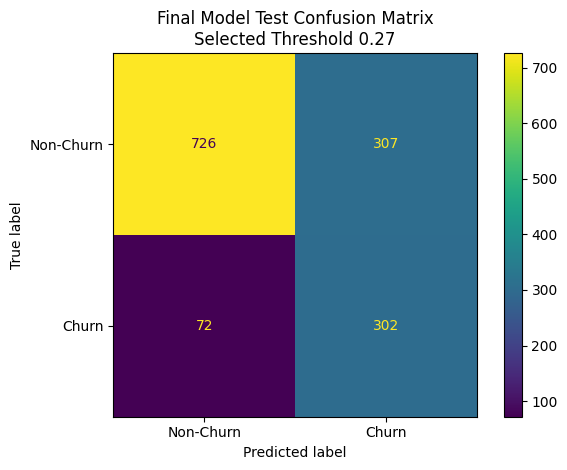

In [26]:
# ==========================================================
# Code Cell 20: Display Final Test Classification Results
# This cell displays classification reports and confusion matrices for the default and selected thresholds.
# ==========================================================

final_prediction_versions = {
    "Default Threshold 0.50":
        test_predictions_default,

    f"Selected Threshold {selected_threshold:.2f}":
        test_predictions_selected
}

for version_name, version_predictions in (
    final_prediction_versions.items()
):

    print("=" * 75)
    print(version_name)
    print("Independent Test Classification Report")
    print("=" * 75)

    print(
        classification_report(
            y_test,
            version_predictions,
            labels=[0, 1],
            target_names=[
                "Non-Churn (0)",
                "Churn (1)"
            ],
            digits=4,
            zero_division=0
        )
    )

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        version_predictions,
        display_labels=[
            "Non-Churn",
            "Churn"
        ],
        values_format="d"
    )

    plt.title(
        f"Final Model Test Confusion Matrix\n"
        f"{version_name}"
    )

    plt.tight_layout()
    plt.show()

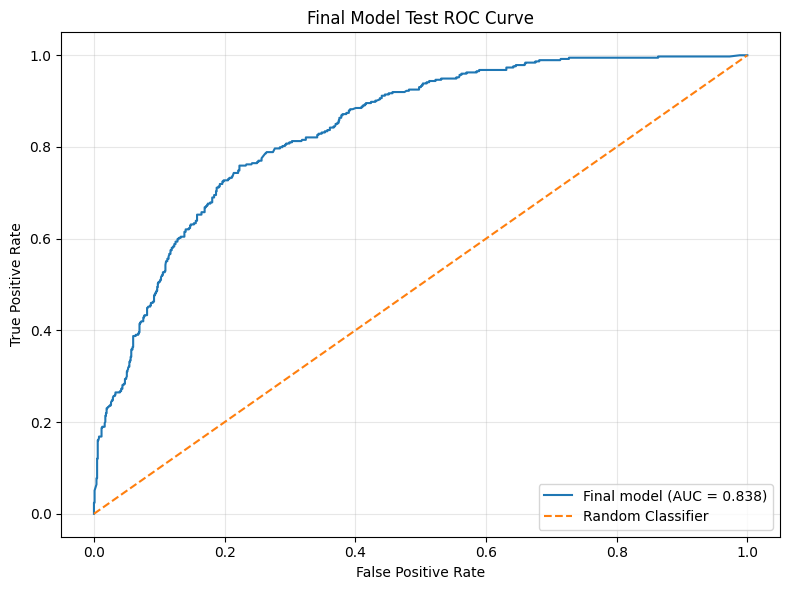

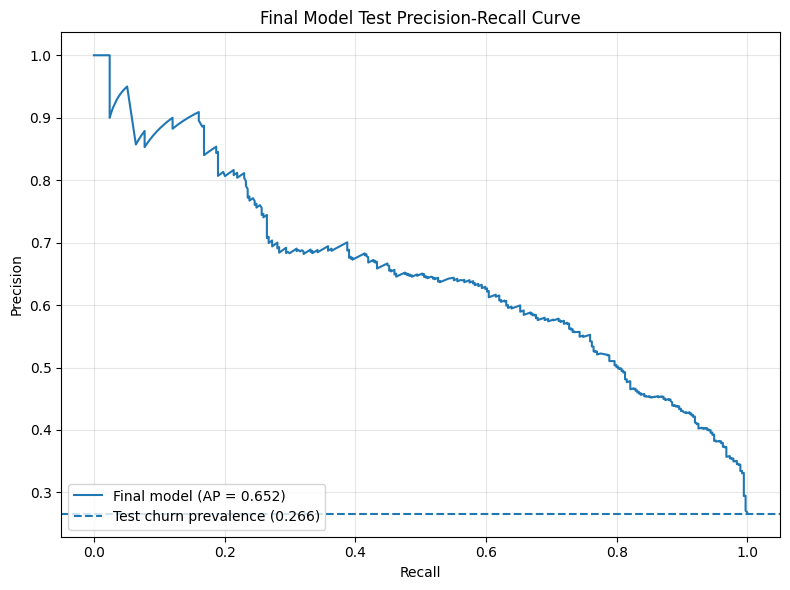

In [27]:
# ==========================================================
# Code Cell 21: Display Final Test Probability Curves
# This cell evaluates the ranking performance of the final model on the independent test dataset.
# ==========================================================

test_false_positive_rate, test_true_positive_rate, _ = (
    roc_curve(
        y_test,
        test_probabilities
    )
)

final_test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    test_false_positive_rate,
    test_true_positive_rate,
    label=(
        f"Final model "
        f"(AUC = {final_test_roc_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


test_precision_values, test_recall_values, _ = (
    precision_recall_curve(
        y_test,
        test_probabilities
    )
)

final_test_average_precision = (
    average_precision_score(
        y_test,
        test_probabilities
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    test_recall_values,
    test_precision_values,
    label=(
        f"Final model "
        f"(AP = {final_test_average_precision:.3f})"
    )
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=(
        "Test churn prevalence "
        f"({y_test.mean():.3f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model Test Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ==========================================================
# Code Cell 22: Create Customer-Level Test Predictions
# This cell connects model predictions and probabilities to the correctly aligned customer identifiers.
# ==========================================================

if not test_reference[
    "ChurnEncoded"
].astype(int).reset_index(drop=True).equals(y_test):

    raise ValueError(
        "Test-reference records are not aligned "
        "with the test target."
    )


test_predictions_df = pd.DataFrame({
    "TestRowIndex":
        np.arange(len(y_test)),

    "customerID":
        test_reference["customerID"],

    "ActualChurn":
        y_test,

    "PredictedChurn":
        test_predictions_selected,

    "PredictedChurn_DefaultThreshold":
        test_predictions_default,

    "ChurnProbability":
        test_probabilities,

    "PredictionThreshold":
        selected_threshold
})

test_predictions_df[
    "ActualChurnLabel"
] = test_predictions_df[
    "ActualChurn"
].map({
    0: "No",
    1: "Yes"
})

test_predictions_df[
    "PredictedChurnLabel"
] = test_predictions_df[
    "PredictedChurn"
].map({
    0: "No",
    1: "Yes"
})

test_customer_predictions_df = (
    test_reference.copy()
)

test_customer_predictions_df[
    "ActualChurnModelTarget"
] = y_test

test_customer_predictions_df[
    "PredictedChurn"
] = test_predictions_selected

test_customer_predictions_df[
    "PredictedChurnLabel"
] = pd.Series(
    test_predictions_selected
).map({
    0: "No",
    1: "Yes"
})

test_customer_predictions_df[
    "PredictedChurn_DefaultThreshold"
] = test_predictions_default

test_customer_predictions_df[
    "ChurnProbability"
] = test_probabilities

test_customer_predictions_df[
    "PredictionThreshold"
] = selected_threshold

print("Customer-level prediction data created.")
print()
print("Prediction output shape:", test_predictions_df.shape)
print(
    "Full customer prediction shape:",
    test_customer_predictions_df.shape
)

print()
print("Highest predicted churn probabilities:")

display(
    test_predictions_df
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
    .head(10)
    .round(4)
)

Customer-level prediction data created.

Prediction output shape: (1407, 9)
Full customer prediction shape: (1407, 28)

Highest predicted churn probabilities:


,TestRowIndex,customerID,ActualChurn,PredictedChurn,PredictedChurn_DefaultThreshold,ChurnProbability,PredictionThreshold,ActualChurnLabel,PredictedChurnLabel
1149,1149,5178-LMXOP,1,1,1,0.8595,0.2700,Yes,Yes
1285,1285,6521-YYTYI,1,1,1,0.8483,0.2700,Yes,Yes
1080,1080,1069-XAIEM,1,1,1,0.8463,0.2700,Yes,Yes
115,115,0970-ETWGE,1,1,1,0.8308,0.2700,Yes,Yes
988,988,3722-WPXTK,1,1,1,0.8249,0.2700,Yes,Yes
902,902,6023-YEBUP,1,1,1,0.8177,0.2700,Yes,Yes
805,805,2609-IAICY,1,1,1,0.8174,0.2700,Yes,Yes
468,468,4415-IJZTP,1,1,1,0.8105,0.2700,Yes,Yes
475,475,7180-PISOG,1,1,1,0.8096,0.2700,Yes,Yes
211,211,5150-ITWWB,0,1,1,0.8086,0.2700,No,Yes


In [31]:
# ==========================================================
# Code Cell 23: Create Training Out-of-Fold Predictions
# This cell saves leakage-safe training probabilities that were generated when each customer was outside its fold.
# ==========================================================

training_oof_predictions_df = pd.DataFrame({
    "TrainingRowIndex":
        np.arange(len(y_train)),

    "customerID":
        train_reference["customerID"],

    "ActualChurn":
        y_train,

    "OutOfFoldChurnProbability":
        selected_oof_probabilities,

    "OutOfFoldPredictedChurn":
        selected_oof_predictions,

    "PredictionThreshold":
        selected_threshold
})

training_oof_predictions_df[
    "ActualChurnLabel"
] = training_oof_predictions_df[
    "ActualChurn"
].map({
    0: "No",
    1: "Yes"
})

training_oof_predictions_df[
    "PredictedChurnLabel"
] = training_oof_predictions_df[
    "OutOfFoldPredictedChurn"
].map({
    0: "No",
    1: "Yes"
})

print(
    "Training out-of-fold prediction file created."
)

print(
    "Output shape:",
    training_oof_predictions_df.shape
)

display(
    training_oof_predictions_df
    .head()
    .round(4)
)

Training out-of-fold prediction file created.
Output shape: (5625, 8)


,TrainingRowIndex,customerID,ActualChurn,OutOfFoldChurnProbability,OutOfFoldPredictedChurn,PredictionThreshold,ActualChurnLabel,PredictedChurnLabel
0,0,1830-GGFNM,0,0.0533,0,0.2700,No,No
1,1,4501-VCPFK,0,0.2634,0,0.2700,No,No
2,2,8871-JLMHM,0,0.0620,0,0.2700,No,No
3,3,0225-ZORZP,0,0.6815,1,0.2700,No,Yes
4,4,1530-ZTDOZ,0,0.1636,0,0.2700,No,No


In [32]:
# ==========================================================
# Code Cell 24: Save Phase 4 Model Development Outputs
# This cell saves the trained model, evaluation results, predictions, parameters, feature names, and metadata.
# ==========================================================

OUTPUT_DIR = "/content/phase4_outputs"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


baseline_comparison_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison_results.csv"
    ),
    index=False
)

cross_validation_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cross_validation_results.csv"
    ),
    index=False
)

stability_analysis_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_stability_results.csv"
    ),
    index=False
)

tuned_candidate_comparison_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tuned_model_comparison.csv"
    ),
    index=False
)

threshold_analysis_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "threshold_analysis.csv"
    ),
    index=False
)

oof_threshold_comparison_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "oof_threshold_comparison.csv"
    ),
    index=False
)

test_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_test_metrics.csv"
    ),
    index=False
)

test_metrics_df[
    [
        "Evaluation",
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "confusion_matrix_results.csv"
    ),
    index=False
)

test_predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_predictions.csv"
    ),
    index=False
)

test_customer_predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_customer_predictions.csv"
    ),
    index=False
)

training_oof_predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "training_oof_predictions.csv"
    ),
    index=False
)

pd.DataFrame({
    "FeaturePosition":
        np.arange(1, X_train.shape[1] + 1),

    "FeatureName":
        X_train.columns
}).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_feature_names.csv"
    ),
    index=False
)

joblib.dump(
    final_model,
    os.path.join(
        OUTPUT_DIR,
        "selected_model.joblib"
    ),
    compress=3
)


def convert_to_serializable(value):

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, dict):
        return {
            str(key): convert_to_serializable(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            convert_to_serializable(item)
            for item in value
        ]

    return value


best_parameters_output = {
    "selected_model_name":
        selected_candidate_name,

    "model_class":
        final_model.__class__.__name__,

    "best_parameters":
        selected_best_parameters,

    "selected_prediction_threshold":
        selected_threshold,

    "target_churn_recall":
        TARGET_CHURN_RECALL
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "best_model_parameters.json"
    ),
    "w",
    encoding="utf-8"
) as parameter_file:

    json.dump(
        convert_to_serializable(
            best_parameters_output
        ),
        parameter_file,
        indent=4
    )


model_metadata = {
    "phase":
        "Phase 4 - Machine Learning Model Development",

    "thesis_title":
        (
            "Design and Evaluation of an Interactive "
            "Visual Analytics System for Explainable "
            "Artificial Intelligence"
        ),

    "selected_model_name":
        selected_candidate_name,

    "model_class":
        final_model.__class__.__name__,

    "model_selection_basis":
        (
            "Training cross-validation PR-AUC, "
            "followed by ROC-AUC and F1-score"
        ),

    "best_parameters":
        selected_best_parameters,

    "random_state":
        RANDOM_STATE,

    "cross_validation_method":
        "StratifiedKFold",

    "cross_validation_folds":
        N_SPLITS,

    "training_records":
        int(len(X_train)),

    "testing_records":
        int(len(X_test)),

    "processed_feature_count":
        int(X_train.shape[1]),

    "feature_names":
        list(X_train.columns),

    "positive_class":
        1,

    "positive_class_description":
        "Customer churn",

    "target_mapping": {
        "No": 0,
        "Yes": 1
    },

    "default_threshold":
        0.50,

    "selected_threshold":
        selected_threshold,

    "target_churn_recall":
        TARGET_CHURN_RECALL,

    "selected_threshold_test_metrics":
        selected_test_metrics,

    "default_threshold_test_metrics":
        default_test_metrics,

    "python_version":
        platform.python_version(),

    "scikit_learn_version":
        sklearn_version,

    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "data_leakage_prevention": [
        (
            "Test data was not used during "
            "cross-validation"
        ),
        (
            "Test data was not used during "
            "hyperparameter tuning"
        ),
        (
            "Test data was not used during "
            "model selection"
        ),
        (
            "Prediction threshold was selected "
            "using training out-of-fold probabilities"
        ),
        (
            "The test dataset was used only for "
            "final independent evaluation"
        )
    ]
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "model_metadata.json"
    ),
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        convert_to_serializable(
            model_metadata
        ),
        metadata_file,
        indent=4
    )


print("All Phase 4 output files were saved.")
print("Output folder:", OUTPUT_DIR)

All Phase 4 output files were saved.
Output folder: /content/phase4_outputs


In [34]:
# ==========================================================
# Code Cell 25: Validate Saved Phase 4 Outputs
# This cell reloads the saved model and confirms that its probabilities match the original final model.
# ==========================================================

saved_model_path = os.path.join(
    OUTPUT_DIR,
    "selected_model.joblib"
)

reloaded_model = joblib.load(
    saved_model_path
)

reloaded_probabilities = (
    reloaded_model.predict_proba(
        X_test
    )[:, 1]
)

probability_match = np.allclose(
    test_probabilities,
    reloaded_probabilities
)

required_output_files = [
    "selected_model.joblib",
    "model_comparison_results.csv",
    "cross_validation_results.csv",
    "model_stability_results.csv",
    "tuned_model_comparison.csv",
    "threshold_analysis.csv",
    "oof_threshold_comparison.csv",
    "final_test_metrics.csv",
    "confusion_matrix_results.csv",
    "test_predictions.csv",
    "test_customer_predictions.csv",
    "training_oof_predictions.csv",
    "model_feature_names.csv",
    "best_model_parameters.json",
    "model_metadata.json"
]

missing_output_files = [
    file_name
    for file_name in required_output_files
    if not os.path.exists(
        os.path.join(
            OUTPUT_DIR,
            file_name
        )
    )
]

print(
    "Reloaded model probabilities match:",
    probability_match
)

print(
    "Missing required output files:",
    len(missing_output_files)
)

if missing_output_files:
    print(missing_output_files)

if not probability_match:
    raise ValueError(
        "The reloaded model does not match "
        "the trained model."
    )

if missing_output_files:
    raise FileNotFoundError(
        "One or more Phase 4 output files are missing."
    )

print()
print("Saved output files:")

for file_name in sorted(
    os.listdir(OUTPUT_DIR)
):
    file_path = os.path.join(
        OUTPUT_DIR,
        file_name
    )

    file_size_kb = (
        os.path.getsize(file_path) / 1024
    )

    print(
        f"- {file_name}: "
        f"{file_size_kb:.2f} KB"
    )

print()
print("Phase 4 output validation passed.")

Reloaded model probabilities match: True
Missing required output files: 0

Saved output files:
- best_model_parameters.json: 0.34 KB
- confusion_matrix_results.csv: 0.11 KB
- cross_validation_results.csv: 4.31 KB
- final_test_metrics.csv: 0.42 KB
- model_comparison_results.csv: 2.46 KB
- model_feature_names.csv: 1.07 KB
- model_metadata.json: 3.67 KB
- model_stability_results.csv: 1.08 KB
- oof_threshold_comparison.csv: 0.41 KB
- selected_model.joblib: 26.76 KB
- test_customer_predictions.csv: 240.02 KB
- test_predictions.csv: 72.41 KB
- threshold_analysis.csv: 8.74 KB
- training_oof_predictions.csv: 280.88 KB
- tuned_model_comparison.csv: 0.65 KB

Phase 4 output validation passed.


In [35]:
# ==========================================================
# Code Cell 26: Create Phase 4 Output ZIP Archive
# This cell combines all model development outputs into one ZIP file for safe storage and later project phases.
# ==========================================================

PHASE4_ZIP_BASE = (
    "/content/Phase_4_Model_Development_Outputs"
)

PHASE4_ZIP_PATH = (
    PHASE4_ZIP_BASE + ".zip"
)

if os.path.exists(PHASE4_ZIP_PATH):
    os.remove(PHASE4_ZIP_PATH)

shutil.make_archive(
    PHASE4_ZIP_BASE,
    "zip",
    OUTPUT_DIR
)

print("Phase 4 ZIP archive created successfully.")
print("ZIP path:", PHASE4_ZIP_PATH)
print(
    "ZIP size:",
    f"{os.path.getsize(PHASE4_ZIP_PATH) / 1024:.2f} KB"
)

Phase 4 ZIP archive created successfully.
ZIP path: /content/Phase_4_Model_Development_Outputs.zip
ZIP size: 230.39 KB


In [37]:
# ==========================================================
# Code Cell 27: Display the Final Phase 4 Summary
# This cell presents the final model, threshold, performance, confusion-matrix results, and saved deliverables.
# ==========================================================

final_selected_row = test_metrics_df[
    test_metrics_df["Evaluation"]
    == "Selected Threshold"
].iloc[0]

print("=" * 72)
print("PHASE 4 — MACHINE LEARNING MODEL DEVELOPMENT SUMMARY")
print("=" * 72)

print()
print("Dataset Information")
print("-" * 72)
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Processed features:", X_train.shape[1])
print("Training churn cases:", int(y_train.sum()))
print("Testing churn cases:", int(y_test.sum()))

print()
print("Model Development")
print("-" * 72)
print("Baseline models evaluated:", len(baseline_models))
print("Cross-validation folds:", N_SPLITS)
print("Hyperparameter tuning: Completed")
print("Test data used during tuning: No")
print("Test data used during threshold selection: No")

print()
print("Selected Model")
print("-" * 72)
print("Model:", selected_candidate_name)
print("Model class:", final_model.__class__.__name__)
print("Best parameters:", selected_best_parameters)
print(
    "Prediction threshold:",
    round(selected_threshold, 4)
)

print()
print("Independent Test Performance")
print("-" * 72)
print(
    "Accuracy:",
    round(final_selected_row["Accuracy"], 4)
)
print(
    "Precision:",
    round(final_selected_row["Precision"], 4)
)
print(
    "Churn Recall:",
    round(final_selected_row["Recall"], 4)
)
print(
    "F1-score:",
    round(final_selected_row["F1"], 4)
)
print(
    "ROC-AUC:",
    round(final_selected_row["ROC_AUC"], 4)
)
print(
    "PR-AUC:",
    round(final_selected_row["PR_AUC"], 4)
)
print(
    "Brier Score:",
    round(final_selected_row["Brier_Score"], 4)
)

print()
print("Confusion Matrix Results")
print("-" * 72)
print(
    "True negatives:",
    int(final_selected_row["TN"])
)
print(
    "False positives:",
    int(final_selected_row["FP"])
)
print(
    "False negatives:",
    int(final_selected_row["FN"])
)
print(
    "True positives:",
    int(final_selected_row["TP"])
)

print()
print("Saved Phase 4 Outputs")
print("-" * 72)

for file_name in sorted(
    os.listdir(OUTPUT_DIR)
):
    print("-", file_name)

print()
print("ZIP archive:")
print(PHASE4_ZIP_PATH)

print()
print("=" * 72)
print(
    "PHASE 4 NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY"
)
print("=" * 72)

PHASE 4 — MACHINE LEARNING MODEL DEVELOPMENT SUMMARY

Dataset Information
------------------------------------------------------------------------
Training records: 5625
Testing records: 1407
Processed features: 45
Training churn cases: 1495
Testing churn cases: 374

Model Development
------------------------------------------------------------------------
Baseline models evaluated: 5
Cross-validation folds: 5
Hyperparameter tuning: Completed
Test data used during tuning: No
Test data used during threshold selection: No

Selected Model
------------------------------------------------------------------------
Model: Tuned Gradient Boosting
Model class: GradientBoostingClassifier
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 30, 'max_depth': 2, 'learning_rate': 0.05}
Prediction threshold: 0.27

Independent Test Performance
------------------------------------------------------------------------
Accuracy: 0.7306
Precision: 0.4959
Churn Recall: 0.8075
F1-score

In [38]:
# ==========================================================
# Code Cell 28: Download the Phase 4 Output ZIP
# This cell downloads all Phase 4 output files to the local computer for safe storage and later SHAP analysis.
# ==========================================================

files.download(
    PHASE4_ZIP_PATH
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>